In [29]:
from sklearn.datasets import load_digits
import pandas as pd
from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import GridSearchCV as gsc
from sklearn.neighbors import KNeighborsClassifier as knc
from sklearn.metrics import confusion_matrix as cm

In [6]:
dataset=load_digits(as_frame=True)
x=dataset.data
y=dataset.target

In [8]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=15)

In [15]:
param_grid={"n_neighbors":[1,3,5,7,9,11,13,15]}
c=gsc(knc(),param_grid,cv=5)

In [16]:
c.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherval

In [17]:
c.best_score_

np.float64(0.9860772357723576)

In [19]:
c.best_params_

{'n_neighbors': 1}

In [23]:
pd.DataFrame(c.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007045,0.001444,0.650028,1.249597,1,{'n_neighbors': 1},0.989583,0.989583,0.993031,0.982578,0.975610,0.986077,0.006241,1
1,0.006690,0.000949,0.040062,0.004153,3,{'n_neighbors': 3},0.975694,0.986111,0.989547,0.986063,0.982578,0.983999,0.004701,3
2,0.006910,0.000894,0.036798,0.004500,5,{'n_neighbors': 5},0.979167,0.979167,0.986063,0.979094,0.982578,0.981214,0.002766,4
3,0.006269,0.000504,0.041861,0.001482,7,{'n_neighbors': 7},0.982639,0.972222,0.986063,0.989547,0.989547,0.984004,0.006424,2
4,0.006368,0.000181,0.043646,0.013580,9,{'n_neighbors': 9},0.979167,0.972222,0.982578,0.975610,0.982578,0.978431,0.004036,5
5,0.006224,0.000370,0.049514,0.011901,11,{'n_neighbors': 11},0.975694,0.968750,0.975610,0.975610,0.979094,0.974952,0.003378,6
6,0.006589,0.000588,0.043821,0.002806,13,{'n_neighbors': 13},0.975694,0.968750,0.975610,0.972125,0.975610,0.973558,0.002762,7
7,0.007178,0.000518,0.048804,0.002401,15,{'n_neighbors': 15},0.975694,0.968750,0.975610,0.968641,0.975610,0.972861,0.003401,8


In [24]:
model=c.best_estimator_

In [25]:
model.score(x_test,y_test)

0.9916666666666667

In [26]:
y_pred=model.predict(x_test)

In [31]:
cmatrix=cm(y_test,y_pred)
cmatrix

array([[31,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 38,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 38,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 27,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 41,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 35,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 38,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 34,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0, 34,  0],
       [ 0,  0,  0,  2,  0,  0,  0,  0,  0, 41]])

<Axes: >

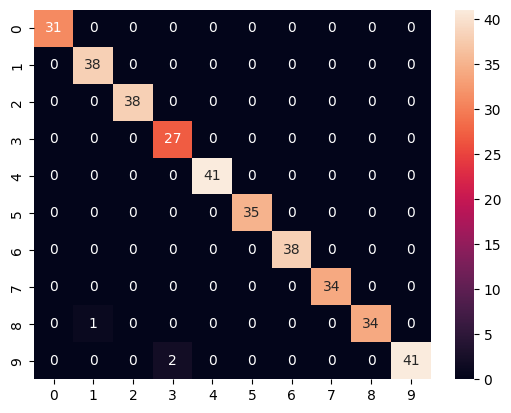

In [32]:
import seaborn as sns
sns.heatmap(cmatrix,annot=True)

In [33]:
from sklearn.metrics import classification_report as cr

In [35]:
print(cr(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.97      1.00      0.99        38
           2       1.00      1.00      1.00        38
           3       0.93      1.00      0.96        27
           4       1.00      1.00      1.00        41
           5       1.00      1.00      1.00        35
           6       1.00      1.00      1.00        38
           7       1.00      1.00      1.00        34
           8       1.00      0.97      0.99        35
           9       1.00      0.95      0.98        43

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

